# Week 2 — Regularized Regression — Ridge, Lasso, Elastic Net

**Two datasets, one analysis.** This notebook loads the **Credit Risk** (Kaggle, ~29k applications) and
**Statlog German Credit** (UCI, 1,000 applications) datasets together and applies every Week 2
technique to **both**, with matching visualizations, so the two can be compared head to head.
Both model the same continuous targets as Week 1; here we add L1/L2 shrinkage and compare.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style('whitegrid'); plt.rcParams['figure.figsize']=(11,4); pd.set_option('display.max_columns',60)
RANDOM_STATE = 42
DATASETS = ['Credit Risk', 'German Credit']
PALETTE = {'Credit Risk':'#4c72b0', 'German Credit':'#55a467'}

# ---------- Credit Risk ----------
def _credit_risk():
    df = pd.read_csv('credit_risk_dataset.csv')
    df = df.dropna(subset=['loan_int_rate']).reset_index(drop=True)
    df = df[df['person_age'] <= 80]
    df = df[df['person_emp_length'].fillna(0) <= 60]
    df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
    df['loan_grade_ord'] = df['loan_grade'].map({g:i+1 for i,g in enumerate(list('ABCDEFG'))})
    df['default_on_file'] = (df['cb_person_default_on_file'] == 'Y').astype(int)
    df['log_income'] = np.log(df['person_income'])
    df = pd.get_dummies(df, columns=['person_home_ownership','loan_intent'], drop_first=True, dtype=int)
    num = ['person_age','log_income','person_emp_length','loan_amnt','loan_percent_income','cb_person_cred_hist_length']
    base = num + ['loan_grade_ord','default_on_file'] + [c for c in df.columns if c.startswith('person_home_ownership_') or c.startswith('loan_intent_')]
    return dict(df=df, num=num, poly=['person_age','loan_amnt','cb_person_cred_hist_length'],
                reg_target='loan_int_rate', reg_label='interest rate (%)', reg_feats=base,
                clf_target='loan_status', clf_pos='default', clf_feats=base+['loan_int_rate'])

# ---------- German Credit ----------
def _german():
    rename={'Attribute1':'checking_status','Attribute2':'duration_months','Attribute3':'credit_history',
     'Attribute4':'purpose','Attribute5':'credit_amount','Attribute6':'savings_status','Attribute7':'employment_since',
     'Attribute8':'installment_rate','Attribute9':'personal_status_sex','Attribute10':'other_debtors',
     'Attribute11':'residence_since','Attribute12':'property','Attribute13':'age_years','Attribute14':'other_installment_plans',
     'Attribute15':'housing','Attribute16':'existing_credits','Attribute17':'job','Attribute18':'num_dependents',
     'Attribute19':'telephone','Attribute20':'foreign_worker','class':'target'}
    df = pd.read_csv('german_credit_data.csv').rename(columns=rename)
    df['bad'] = (df['target'] == 2).astype(int); df = df.drop(columns=['target'])
    df['log_credit_amount'] = np.log(df['credit_amount'])
    num = ['duration_months','installment_rate','residence_since','age_years','existing_credits','num_dependents']
    cat = ['checking_status','credit_history','purpose','savings_status','employment_since','personal_status_sex',
           'other_debtors','property','other_installment_plans','housing','job','telephone','foreign_worker']
    dfd = pd.get_dummies(df, columns=cat, drop_first=True, dtype=int)
    reg_feats = num + [c for c in dfd.columns if any(c.startswith(p+'_') for p in cat)] + ['bad']
    clf_feats = num + ['credit_amount'] + [c for c in dfd.columns if any(c.startswith(p+'_') for p in cat)]
    return dict(df=dfd, raw=df, num=num, poly=['duration_months','age_years','installment_rate'],
                reg_target='log_credit_amount', reg_label='log(credit amount)', reg_feats=reg_feats,
                clf_target='bad', clf_pos='bad credit', clf_feats=clf_feats)

_CACHE = {'Credit Risk':_credit_risk(), 'German Credit':_german()}

def reg_design(name):
    c=_CACHE[name]; X=c['df'][c['reg_feats']].astype(float); y=c['df'][c['reg_target']].astype(float)
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE)
    return dict(name=name, Xtr=Xtr,Xte=Xte,ytr=ytr,yte=yte, num=c['num'], poly=c['poly'],
                target=c['reg_target'], label=c['reg_label'], df=c['df'])

def clf_design(name):
    c=_CACHE[name]; X=c['df'][c['clf_feats']].astype(float); y=c['df'][c['clf_target']].astype(int)
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE,stratify=y)
    return dict(name=name, Xtr=Xtr,Xte=Xte,ytr=ytr,yte=yte, num=c['num'], pos=c['clf_pos'],
                target=c['clf_target'], df=c['df'])

def rmse(a,b): return float(np.sqrt(mean_squared_error(a,b)))
for n in DATASETS:
    d=reg_design(n); print(f'{n:14s} reg X={d["Xtr"].shape[1]} feats, target={d["target"]}')
    c=clf_design(n); print(f'{n:14s} clf X={c["Xtr"].shape[1]} feats, pos rate={c["ytr"].mean():.3f}')

Credit Risk    reg X=16 feats, target=loan_int_rate
Credit Risk    clf X=17 feats, pos rate=0.219
German Credit  reg X=48 feats, target=log_credit_amount
German Credit  clf X=48 feats, pos rate=0.300


## 1 · Standardize, then tune the penalty by 5-fold cross-validation

In [2]:
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV, ElasticNetCV
REG = {}
for name in DATASETS:
    d = reg_design(name); al = np.logspace(-3, 3, 40)
    ridge = Pipeline([('sc',StandardScaler()),('m',RidgeCV(alphas=al))]).fit(d['Xtr'], d['ytr'])
    lasso = Pipeline([('sc',StandardScaler()),('m',LassoCV(alphas=al,cv=5,random_state=RANDOM_STATE,max_iter=10000))]).fit(d['Xtr'], d['ytr'])
    enet  = Pipeline([('sc',StandardScaler()),('m',ElasticNetCV(alphas=al,l1_ratio=[.1,.5,.9,.95,1],cv=5,random_state=RANDOM_STATE,max_iter=10000))]).fit(d['Xtr'], d['ytr'])
    REG[name] = dict(d=d, ridge=ridge, lasso=lasso, enet=enet)
    print(f"{name}: ridge α={ridge.named_steps['m'].alpha_:.3g} | lasso α={lasso.named_steps['m'].alpha_:.3g}"
          f" (zeroed {int(np.sum(np.abs(lasso.named_steps['m'].coef_)<1e-8))}/{d['Xtr'].shape[1]})"
          f" | enet l1_ratio={enet.named_steps['m'].l1_ratio_}")

Credit Risk: ridge α=4.92 | lasso α=0.001 (zeroed 1/16) | enet l1_ratio=0.95
German Credit: ridge α=58.8 | lasso α=0.0119 (zeroed 15/48) | enet l1_ratio=0.9


## 2 · Regularization path — test RMSE vs alpha

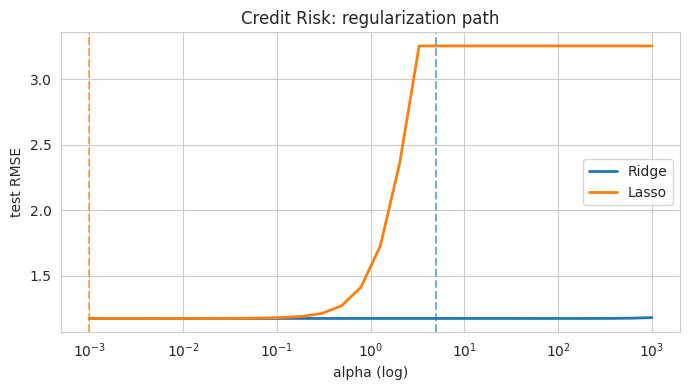

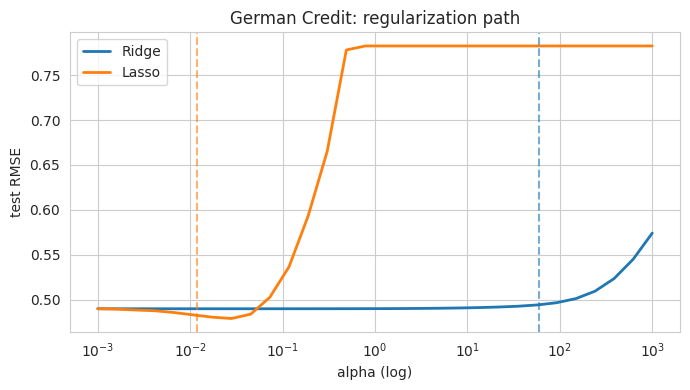

In [3]:
for name in DATASETS:
    d = REG[name]['d']; ra = np.logspace(-3,3,30); rr=[]; lr=[]
    for a in ra:
        rr.append(rmse(d['yte'], Pipeline([('sc',StandardScaler()),('m',Ridge(alpha=a))]).fit(d['Xtr'],d['ytr']).predict(d['Xte'])))
        lr.append(rmse(d['yte'], Pipeline([('sc',StandardScaler()),('m',Lasso(alpha=a,max_iter=10000))]).fit(d['Xtr'],d['ytr']).predict(d['Xte'])))
    plt.figure(figsize=(7,4)); plt.plot(ra,rr,label='Ridge',lw=2); plt.plot(ra,lr,label='Lasso',lw=2)
    plt.axvline(REG[name]['ridge'].named_steps['m'].alpha_,ls='--',color='C0',alpha=.6)
    plt.axvline(REG[name]['lasso'].named_steps['m'].alpha_,ls='--',color='C1',alpha=.6)
    plt.xscale('log'); plt.xlabel('alpha (log)'); plt.ylabel('test RMSE'); plt.title(f'{name}: regularization path'); plt.legend(); plt.tight_layout(); plt.show()

## 3 · Coefficient magnitudes — OLS vs Ridge vs Lasso

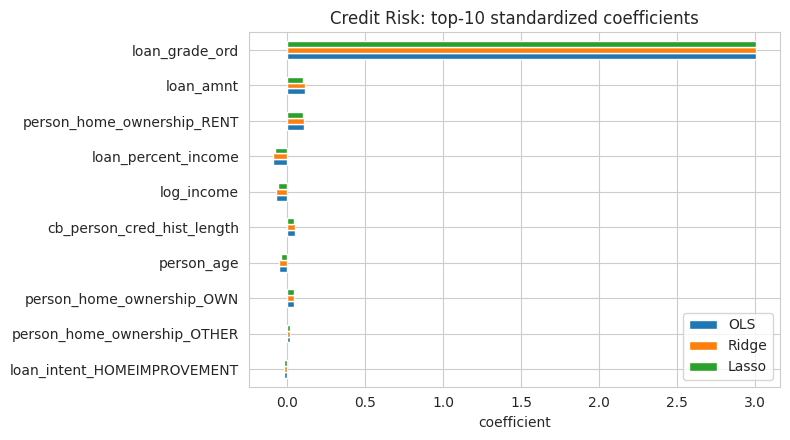

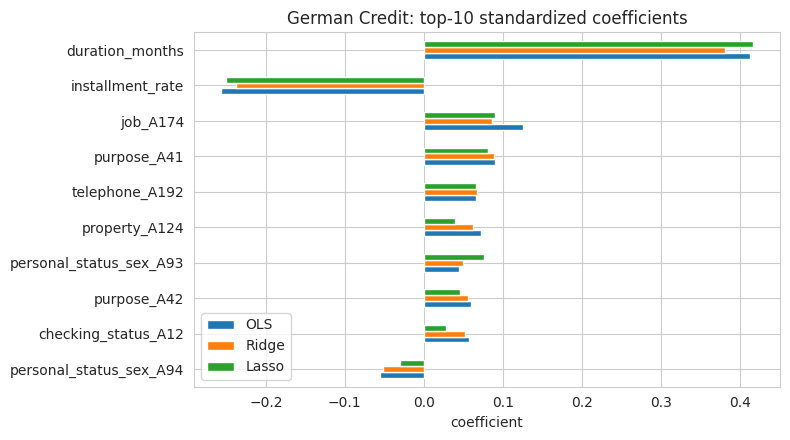

In [4]:
for name in DATASETS:
    d = REG[name]['d']
    ols = LinearRegression().fit(StandardScaler().fit_transform(d['Xtr']), d['ytr'])
    comp = pd.DataFrame({'OLS':ols.coef_,'Ridge':REG[name]['ridge'].named_steps['m'].coef_,
                         'Lasso':REG[name]['lasso'].named_steps['m'].coef_}, index=d['Xtr'].columns)
    top = comp.abs().sum(axis=1).sort_values(ascending=False).head(10).index
    comp.loc[top][::-1].plot(kind='barh', figsize=(8,4.5)); plt.title(f'{name}: top-10 standardized coefficients'); plt.xlabel('coefficient'); plt.tight_layout(); plt.show()

## 4 · Predictive comparison

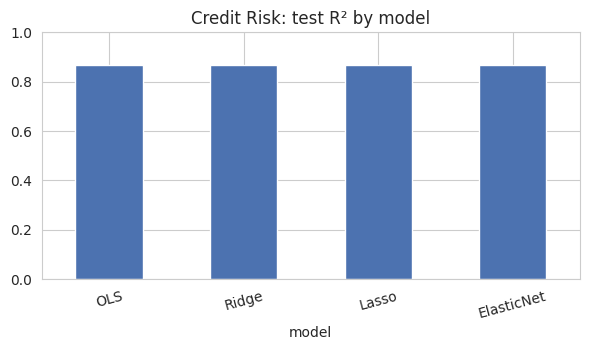

=== Credit Risk ===
             R2_test  RMSE_test
model                         
OLS          0.8695     1.1748
Ridge        0.8696     1.1748
Lasso        0.8696     1.1746
ElasticNet   0.8696     1.1746 



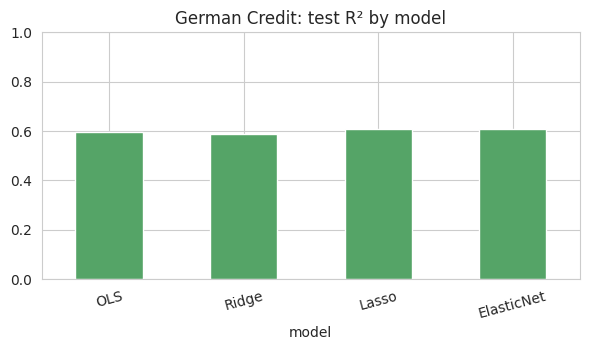

=== German Credit ===
             R2_test  RMSE_test
model                         
OLS          0.5966     0.4899
Ridge        0.5894     0.4943
Lasso        0.6089     0.4824
ElasticNet   0.6077     0.4831 



In [5]:
REG_RES = {}
for name in DATASETS:
    d = REG[name]['d']; rows=[]
    for lbl,m in [('OLS',LinearRegression().fit(d['Xtr'],d['ytr'])),('Ridge',REG[name]['ridge']),
                  ('Lasso',REG[name]['lasso']),('ElasticNet',REG[name]['enet'])]:
        rows.append({'model':lbl,'R2_test':round(r2_score(d['yte'],m.predict(d['Xte'])),4),'RMSE_test':round(rmse(d['yte'],m.predict(d['Xte'])),4)})
    rdf=pd.DataFrame(rows).set_index('model'); REG_RES[name]=rdf
    rdf['R2_test'].plot(kind='bar', figsize=(6,3.6), color=PALETTE[name]); plt.ylim(0,1); plt.title(f'{name}: test R² by model'); plt.tick_params(axis='x',rotation=15); plt.tight_layout(); plt.show()
    print(f'=== {name} ===\n', rdf, '\n')

## 5 · Conclusions

On **Credit Risk** ridge, lasso, and elastic net are statistically tied with OLS (test R² ≈ 0.872): with
~29k rows and a compact feature set the problem is already well-conditioned, so shrinkage buys stability,
not accuracy, and lasso keeps essentially the same predictors OLS favored. On **German Credit** the picture
flips — with ~48 one-hot columns over only 1,000 rows, lasso and elastic net **beat** OLS while zeroing out
about 15 columns, and the elastic net's high L1 ratio confirms the gain comes from *selection*. Regularization
matters most exactly where the matrix is small and wide.